In [1]:
from langchain_chroma import Chroma
from langchain_upstage import UpstageEmbeddings
from dotenv import load_dotenv

load_dotenv()

embedding_function = UpstageEmbeddings(model='solar-embedding-1-large')

# Chroma DB의 Collection을 불러온다 
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'pension_law_collection',
    persist_directory = './pension_law_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k':3})

In [2]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str # 질문
    context: List[Document] # 참고할 문서
    answer: str # 답변

graph_builder = StateGraph(AgentState)    

In [3]:
def retrieve(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 검색된 문서가 추가된 state를 반환합니다.
    """
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [4]:
from langchain_upstage import ChatUpstage

llm = ChatUpstage()

In [5]:
from langchain_core.prompts import PromptTemplate

generate_prompt = PromptTemplate.from_template("""
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.

Question: {question}

Context: {context}

Answer:
""")

def generate(state: AgentState) -> AgentState:
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    rag_chain = generate_prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.  LCEC 기법
    response = rag_chain.invoke({'question': query, 'context': context})  # 질문과 문맥을 사용하여 응답을 생성합니다.
    return {'answer': response}  # 생성된 응답을 포함한 state를 반환합니다.

In [ ]:
from langsmith import Client
from typing import Literal

client = Client()
doc_relevance_prompt = client.pull_prompt(
    "langchain-ai/rag-document-relevance",
    dangerously_pull_public_prompt=True,
)

def check_doc_relevance(state: AgentState)  -> Literal['generate', 'rewrite']:

    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    print(f'context == {context}')
    doc_relevance_chain = doc_relevance_prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.  LCEC 기법
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})  # 질문과 문맥을 사용하여 응답을 생성합니다.
    print(f'doc relevance response == {response}')
    if response['Score'] == 1:
        return 'generate'
    
    return 'rewrite'

In [7]:
query = '일반적으로 직장인은 언제 연금을 수령할수 있나요?'

In [8]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = dictionary = [
    "직장인 -> 사업장가입자",
    "회사원 -> 사업장가입자",
    "근로자 -> 사업장가입자",
    "개인사업자 -> 지역가입자",
    "자영업자 -> 지역가입자",
    "프리랜서 -> 지역가입자",
    "학생 -> 임의가입자",
    "전업주부 -> 임의가입자",
    "주부 -> 임의가입자",
    "외국인 -> 외국인가입자",
    "연금 보험료 -> 연금보험료",
    "국민연금 보험료 -> 연금보험료",
    "보험료 미납 -> 연금보험료 체납",
    "연금 못 냄 -> 연금보험료 체납",
    "가입 해지 -> 가입자 자격 상실",
    "탈퇴 -> 가입자 자격 상실",
    "가입 시작일 -> 자격 취득 시기",
    "가입 끝나는 날 -> 자격 상실 시기",
    "수급자 -> 수급권자",
    "연금 받는 사람 -> 수급권자",
    "노후연금 -> 노령연금",
    "장애 보상 -> 장애연금",
    "사망 후 연금 -> 유족연금",
    "배우자 연금 -> 유족연금",
]

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.

사전: {dictionary}
질문: {{query}}
""")

def rewrite(state: AgentState) -> AgentState:
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    rewrite_chain = rewrite_prompt | llm | StrOutputParser() # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.  LCEC 기법
    response = rewrite_chain.invoke({'query': query})  # StrOutputParser을 해주면 response 'str'로 변경됨
    return {'query': response}  # 생성된 응답을 포함한 state를 반환합니다.

In [9]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [10]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges("retrieve",check_doc_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

In [11]:
graph = graph_builder.compile()

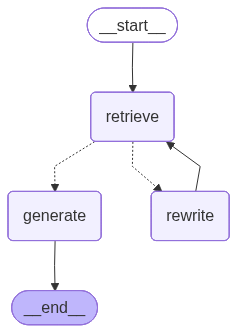

In [12]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
initial_state = {'query': query}
graph.invoke(initial_state)

context == [Document(id='02cc2e61-fa1c-47b1-9e3f-7ee084fc0777', metadata={'source': './documents/pension_law.txt'}, page_content='제59조(미납금의 공제 지급) ① 가입자 또는 가입자였던 자가 수급권을 취득하거나 사망한 경우 제46조에 따라 대여한\n자금의 상환금에 관한 채무가 있으면 이를 이 법에 따른 급여(사망일시금을 포함하고 지급이 정지된 급여는 제외한\n다)에서 공제할 수 있다. 다만, 이 법에 따른 급여 중 연금급여(제68조제2항에 따라 일시보상금으로 지급되는 장애연\n금은 제외한다)의 수급권자에 대하여는 해당 연금월액의 2분의 1을 초과하여 공제할 수 없다.\n② 제1항에 따라 해당 상환금에 관한 채무를 공제하려면 20일 이상의 기한을 정하여 문서로 그 채무의 변제를 최고\n(催告)하여야 하며, 그 기한까지 채무를 변제하지 아니하면 해당 급여에서 공제할 것임을 미리 수급권자에게 통지하\n여야 한다.\n③ 제1항에 따라 공제한 금액은 그 액수만큼 수급권자에게 지급된 것으로 본다.\n제60조(조세와 그 밖의 공과금 면제) 이 법에 따른 급여로 지급된 금액에 대하여는 「조세특례제한법」이나 그 밖의 법\n률 또는 지방자치단체가 조례로 정하는 바에 따라 조세, 그 밖에 국가 또는 지방자치단체의 공과금을 감면한다.\n제2절 노령연금\n제61조(노령연금 수급권자) ① 가입기간이 10년 이상인 가입자 또는 가입자였던 자에 대하여는 60세(특수직종근로자는\n55세)가 된 때부터 그가 생존하는 동안 노령연금을 지급한다. <개정 2011. 12. 31.>\n② 가입기간이 10년 이상인 가입자 또는 가입자였던 자로서 55세 이상인 자가 대통령령으로 정하는 소득이있는 업\n무에 종사하지 아니하는 경우 본인이 희망하면 제1항에도 불구하고 60세가 되기 전이라도 본인이 청구한 때부터\n그가 생존하는 동안 일정한 금액의 연금(이하 “조기노령연금”이라 한다)을 받을 수 있다.<개

{'query': '일반적으로 사업장가입자는 언제 노령연금을 수령할 수 있나요?',
 'context': [Document(id='02cc2e61-fa1c-47b1-9e3f-7ee084fc0777', metadata={'source': './documents/pension_law.txt'}, page_content='제59조(미납금의 공제 지급) ① 가입자 또는 가입자였던 자가 수급권을 취득하거나 사망한 경우 제46조에 따라 대여한\n자금의 상환금에 관한 채무가 있으면 이를 이 법에 따른 급여(사망일시금을 포함하고 지급이 정지된 급여는 제외한\n다)에서 공제할 수 있다. 다만, 이 법에 따른 급여 중 연금급여(제68조제2항에 따라 일시보상금으로 지급되는 장애연\n금은 제외한다)의 수급권자에 대하여는 해당 연금월액의 2분의 1을 초과하여 공제할 수 없다.\n② 제1항에 따라 해당 상환금에 관한 채무를 공제하려면 20일 이상의 기한을 정하여 문서로 그 채무의 변제를 최고\n(催告)하여야 하며, 그 기한까지 채무를 변제하지 아니하면 해당 급여에서 공제할 것임을 미리 수급권자에게 통지하\n여야 한다.\n③ 제1항에 따라 공제한 금액은 그 액수만큼 수급권자에게 지급된 것으로 본다.\n제60조(조세와 그 밖의 공과금 면제) 이 법에 따른 급여로 지급된 금액에 대하여는 「조세특례제한법」이나 그 밖의 법\n률 또는 지방자치단체가 조례로 정하는 바에 따라 조세, 그 밖에 국가 또는 지방자치단체의 공과금을 감면한다.\n제2절 노령연금\n제61조(노령연금 수급권자) ① 가입기간이 10년 이상인 가입자 또는 가입자였던 자에 대하여는 60세(특수직종근로자는\n55세)가 된 때부터 그가 생존하는 동안 노령연금을 지급한다. <개정 2011. 12. 31.>\n② 가입기간이 10년 이상인 가입자 또는 가입자였던 자로서 55세 이상인 자가 대통령령으로 정하는 소득이있는 업\n무에 종사하지 아니하는 경우 본인이 희망하면 제1항에도 불구하고 60세가 되기 전이라도 본인이 청구한 때부터\n그가 